# Ranking Stability Analysis

The Experience-Centered AI framework relies on a weighted scoring model.

While the initial rankings use a specific set of weights, alternative weighting schemes could produce different results.

To test ranking robustness, a Monte Carlo simulation is used to generate 10,000 random weighting combinations.

This analysis evaluates whether highly-ranked companies remain strong performers under a wide range of assumptions.

In [1]:
# =====================================================
# Experience-Centered AI Analysis
# Notebook 3: Ranking Stability Analysis
#
# Purpose:
# - Test robustness of company rankings
# - Evaluate alternative weighting schemes
# - Identify companies with stable performance
# =====================================================

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd

from scripts.scoring_utils import (
    run_monte_carlo_sensitivity,
    summarize_sensitivity
)

from scripts.visualization import (
    save_sensitivity_chart
)

In [2]:
# Load scoring data

DATA_PATH = project_root / "data" / "raw" / "scoring.csv"
CHART_DIR = project_root / "charts"

df = pd.read_csv(DATA_PATH)

df.head()

,company_id,company,industry,experience_intensity,ai_enhancement,repeat_usage,agency_preservation,revenue_capture,network_effects,experience_ai_score
0,1,Peloton,Fitness,10,9,8,9,8,6,8.65
1,2,Planet Fitness,Fitness,7,6,7,8,8,4,6.75
2,3,Duolingo,Education,9,10,10,9,9,7,9.20
3,4,Coursera,Education,8,8,7,8,7,5,7.40
4,5,Roblox,Gaming,10,9,10,10,9,10,9.70


In [3]:
# Generate 10,000 random weighting schemes

results = run_monte_carlo_sensitivity(
    df,
    n_simulations=10000
)

results.head()

,simulation,company,simulated_score,rank
0,1,Peloton,8.747716,6.0
1,1,Planet Fitness,6.597185,14.0
2,1,Duolingo,9.659305,1.0
3,1,Coursera,7.670129,11.0
4,1,Roblox,9.474274,2.0


## Monte Carlo Methodology

Each simulation generates a unique weighting combination across the six framework dimensions.

Weights are constrained to sum to 100%.

Company scores are recalculated and ranked for every simulation.

This process allows ranking stability to be evaluated across a broad range of reasonable assumptions.

In [4]:
# Summarize ranking stability

summary = summarize_sensitivity(
    results
)

summary

,company,average_rank,median_rank,best_rank,worst_rank,top_3_frequency,average_score
12,Roblox,1.0637,1.0,1.0,3.0,1.0000,9.668946
4,Duolingo,2.5497,2.0,1.0,7.0,0.8478,8.998698
8,Match Group,2.9827,3.0,2.0,6.0,0.7833,8.831839
2,Bumble,5.0704,5.0,3.0,10.0,0.0036,8.499559
10,Peloton,6.0433,6.0,2.0,13.0,0.1776,8.333657
5,Electronic Arts,7.0368,7.0,4.0,10.0,0.0000,8.165141
14,Spotify,7.1868,7.0,3.0,13.0,0.0397,8.164461
0,Airbnb,7.7026,8.0,2.0,16.0,0.1192,7.998508
9,Netlix,7.8904,8.0,3.0,16.0,0.0205,7.994722
6,HelloFresh,9.6302,10.0,3.0,14.0,0.0003,7.668956


## Top 3 Frequency

Top 3 Frequency measures how often a company appears among the three highest-ranked companies across all simulations.

A high value indicates that a company's position is robust to changes in framework assumptions.

Companies that remain highly ranked under many alternative weighting schemes are more likely to represent structural leaders under the Experience-Centered AI thesis.

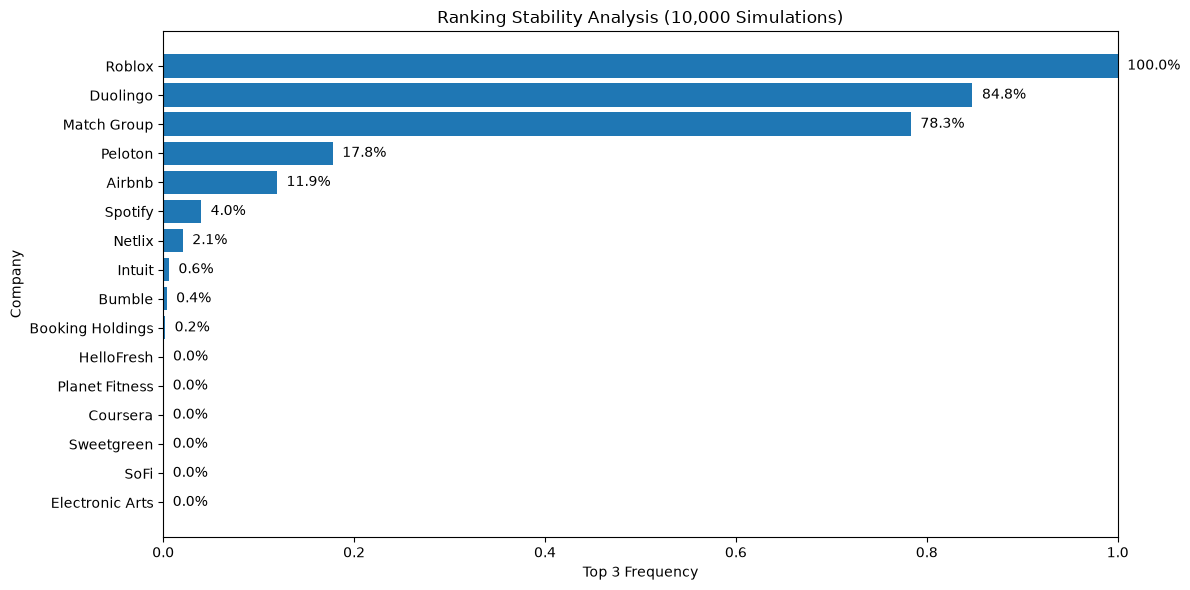

In [5]:
# Create ranking stability visualization

save_sensitivity_chart(
    summary,
    CHART_DIR
)

In [6]:
# Identify the most consistently high-ranking companies

summary.sort_values(
    "top_3_frequency",
    ascending=False
)[
    [
        "company",
        "average_rank",
        "top_3_frequency"
    ]
]

,company,average_rank,top_3_frequency
12,Roblox,1.0637,1.0000
4,Duolingo,2.5497,0.8478
8,Match Group,2.9827,0.7833
10,Peloton,6.0433,0.1776
0,Airbnb,7.7026,0.1192
14,Spotify,7.1868,0.0397
9,Netlix,7.8904,0.0205
7,Intuit,10.9819,0.0060
2,Bumble,5.0704,0.0036
1,Booking Holdings,12.5827,0.0020


In [7]:
# Measure ranking range

summary[
    [
        "company",
        "best_rank",
        "worst_rank"
    ]
].sort_values("best_rank")

,company,best_rank,worst_rank
12,Roblox,1.0,3.0
4,Duolingo,1.0,7.0
1,Booking Holdings,1.0,16.0
7,Intuit,1.0,16.0
0,Airbnb,2.0,16.0
10,Peloton,2.0,13.0
8,Match Group,2.0,6.0
2,Bumble,3.0,10.0
6,HelloFresh,3.0,14.0
14,Spotify,3.0,13.0


## Ranking Volatility

Best Rank and Worst Rank provide a measure of ranking variability.

Companies with narrow ranking ranges demonstrate stability across different weighting assumptions.

Companies with wider ranking ranges may be more sensitive to specific dimensions of the framework.

In [8]:
# Save stability outputs

OUTPUT_DIR = project_root / "data" / "outputs"

summary.to_csv(
    OUTPUT_DIR / "ranking_stability_summary.csv",
    index=False
)

results.to_csv(
    OUTPUT_DIR / "ranking_stability_simulations.csv",
    index=False
)

print("Ranking stability outputs saved.")

Ranking stability outputs saved.


# Alternative Hypothesis Considerations

The Experience-Centered AI framework favors companies that preserve participation, agency, mastery, engagement, and identity formation.

However, the simulation results indicate that alternative weighting schemes can produce substantially different rankings.

For example, Intuit achieved the highest rank in a subset of simulations despite ranking lower on average. Similarly, Booking Holdings occasionally performed strongly when monetization and operational characteristics received greater emphasis.

These findings suggest that the long-term winners of the AI era may depend on whether markets ultimately reward experience enhancement or operational efficiency more heavily.

While the framework identifies Roblox, Duolingo, and Match Group as the most robust opportunities under the Experience-Centered AI thesis, the results do not eliminate the possibility that utility-oriented companies could outperform under a different conception of AI value creation.

As a result, the framework should be viewed as an analytical lens for evaluating one possible future of AI rather than a definitive forecast.

# Ranking Stability Findings

The Monte Carlo simulation evaluated ranking robustness across 10,000 alternative weighting schemes.

Key observations:

1. Roblox demonstrated exceptional stability, maintaining an average rank of 1.06 and appearing in the Top 3 in 100% of simulations.

2. Duolingo and Match Group also exhibited strong robustness, appearing in the Top 3 in approximately 85% and 78% of simulations, respectively.

3. The highest-ranked companies consistently combined engagement, personalization, repeat participation, and preserved user agency.

4. Companies such as Peloton, Airbnb, Spotify, and Netflix occasionally entered the Top 3, but their rankings were more sensitive to changes in framework assumptions.

5. Several companies with strong monetization characteristics performed well under specific weighting schemes but lacked the consistency demonstrated by the top-ranked firms.

Overall, the results suggest that a relatively small group of companies exhibit broad alignment with the Experience-Centered AI framework across a wide range of alternative assumptions.